In [17]:
import sys
# Path to implicit filter library
sys.path.append("/albedo/home/rjuhrban/implicit_filter/src/implicit_filter/")
from jax_filter import JaxFilter

# For data processing
import xarray as xr
import numpy as np

path = "/albedo/work/projects/p_clidyn_work/rjuhrban/channel/test_10/results/training_with_vertical_and_rossby_scaling/"
meshdiag = xr.open_dataset(path+"fesom.mesh.diag.nc")
str_id = "temp"
ds = xr.open_zarr(path+str_id+".zarr").isel(time=-1, nz1=0).compute()

flter = JaxFilter()

# Only have to prepare it once
flter.prepare_from_file("/albedo/home/rjuhrban/channel/meshfiles_10km/fesom.mesh.diag.nc")
flter.save_to_file("/albedo/home/rjuhrban/channel/meshfiles_10km/filter_cash")

In [18]:
# Load prepared filter
flter = JaxFilter.load_from_file("/albedo/home/rjuhrban/channel/meshfiles_10km/filter_cash.npz")

In [33]:
# Create wavenumber array from lengths

from _auxiliary import convert_to_wavenumbers

# Mesh resolution in km (can be any unit, but distances have to be 
# in the same unit)
dxm = 40 

# Wavelengths you want to filter
distance = np.arange(10,2_000,20)

# Convert wavelengths to wavenumbers
Kc = np.array([convert_to_wavenumbers(distance[i], dxm) for i in range(len(distance))])

# Not sure why this is done, but it works
k = np.insert(Kc, 0, 2*Kc[0])

# No explanation needed :)
nr = len(k)

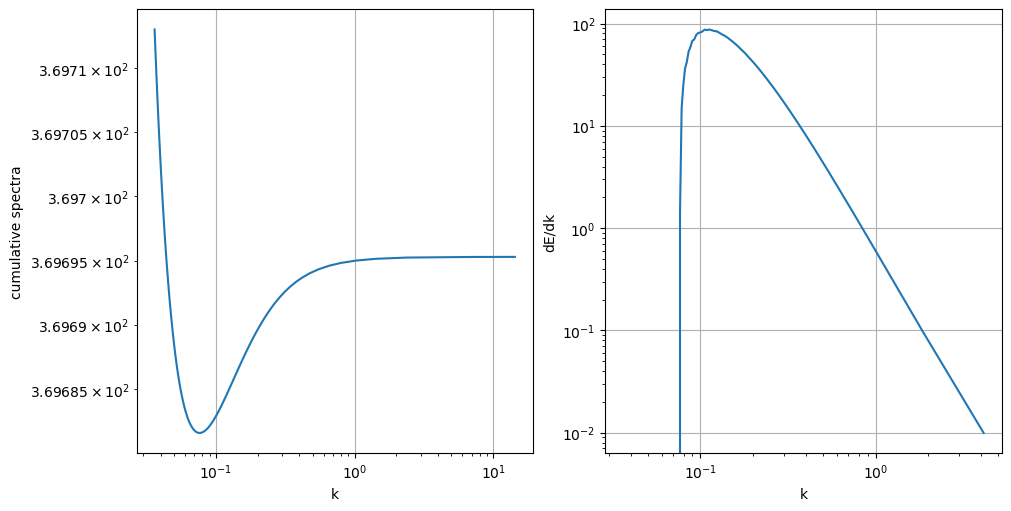

In [37]:
# Calculate dE/dk and plot
import matplotlib.pyplot as plt

# This has to be something like a numpy array
# (not xarray DataArray)
unfiltered = ds[str_id].data

# Apply the filter
filtered_values = np.array([flter.compute(n=1, k=k[i], data=unfiltered) for i in range(nr)])

# Used for calculating weighted power spectrum
area = meshdiag["nod_area"].isel(nz=0)

# Calculate spectra
spectra = np.array([np.sum(area * np.square( filtered_values[i])) / np.sum(area) for i in range(nr)])

# For plotting and de/dk calculation
dk = k[1:] - k[0:-1]
kmid = np.sqrt(k[0:-1] * k[1:])
de  = spectra[0:-1] - spectra[1:]

fig, axes = plt.subplots(figsize=(10, 5), ncols=2, constrained_layout=True)

# Cumulative spectra
axes[0].plot(k, spectra, label="true")
axes[0].set_xlabel("k")
axes[0].set_ylabel("cumulative spectra")
axes[0].grid()
axes[0].set_xscale("log")
axes[0].set_yscale("log")

# dE/dk
# Not sure why * 1000
axes[1].plot(kmid[1:], -(de[1:] / dk[1:]) * 1000)
axes[1].set_xlabel("k")
axes[1].set_ylabel("dE/dk")
axes[1].grid()
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_label("true")